In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

PASTA_CLEAN  = Path("../data/clean")
PASTA_VISUAL = Path("../visuals")
PASTA_VISUAL.mkdir(exist_ok=True)

comparacao = pd.read_csv(PASTA_CLEAN / "comparacao_2014_2024.csv")


plt.rcParams.update({
    "font.family":   "sans-serif",
    "font.size":     14,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "axes.spines.top":    False, 
    "axes.spines.right":  False,  
    "figure.dpi":    150,
})

COR_EAD        = "#2563EB"  
COR_PRESENCIAL = "#64748B"  
COR_FUNDO      = "#F8FAFC"

print("Setup concluído.")

Setup concluído.


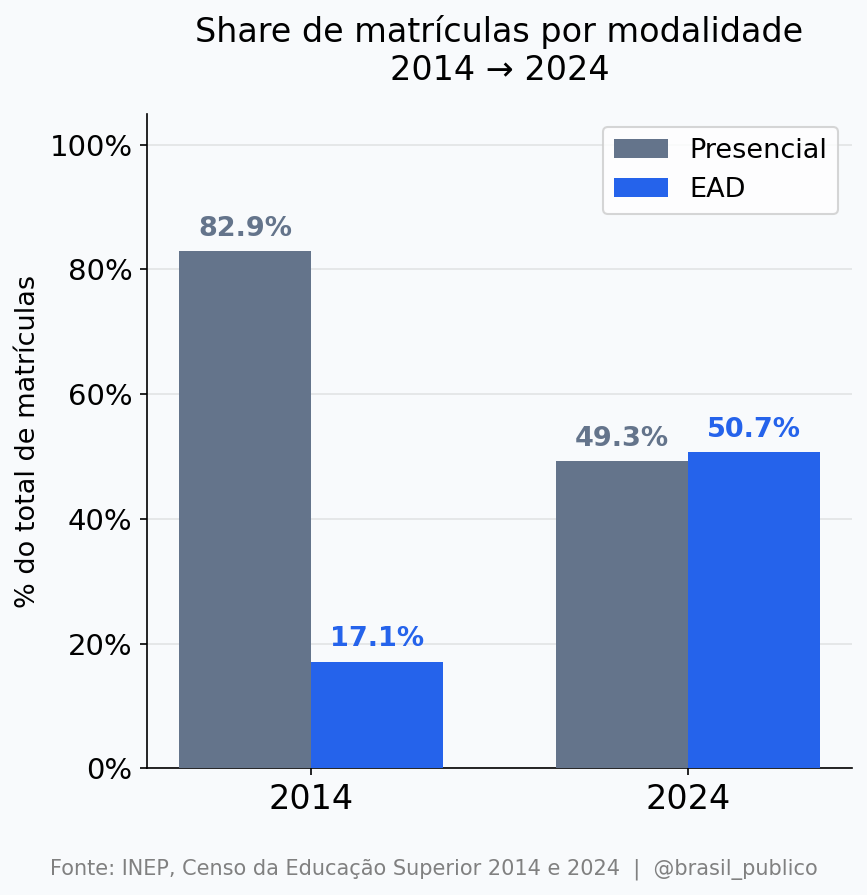

Salvo: grafico1_share_modalidade.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

anos = [2014, 2024]
ead        = [17.1, 50.7]
presencial = [82.9, 49.3]

x = range(len(anos))
largura = 0.35

barras_pres = ax.bar(
    [i - largura/2 for i in x], presencial,
    width=largura, color=COR_PRESENCIAL, label="Presencial", zorder=3
)
barras_ead = ax.bar(
    [i + largura/2 for i in x], ead,
    width=largura, color=COR_EAD, label="EAD", zorder=3
)

for barra in barras_pres:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1.5,
        f"{barra.get_height():.1f}%",
        ha="center", va="bottom", fontsize=13,
        color=COR_PRESENCIAL, fontweight="bold"
    )
for barra in barras_ead:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1.5,
        f"{barra.get_height():.1f}%",
        ha="center", va="bottom", fontsize=13,
        color=COR_EAD, fontweight="bold"
    )

ax.set_xticks(list(x))
ax.set_xticklabels(["2014", "2024"], fontsize=16)
ax.set_ylabel("% do total de matrículas", fontsize=13)
ax.set_ylim(0, 105) 
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.legend(fontsize=13, loc="upper right")
ax.set_title(
    "Share de matrículas por modalidade\n2014 → 2024",
    fontsize=16, pad=16
)
fig.text(
    0.5, 0.01,
    "Fonte: INEP, Censo da Educação Superior 2014 e 2024  |  @brasil_publico",
    ha="center", fontsize=10, color="gray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PASTA_VISUAL / "grafico1_share_modalidade.png",
            dpi=150, bbox_inches="tight", facecolor=COR_FUNDO)
plt.show()
print("Salvo: grafico1_share_modalidade.png")

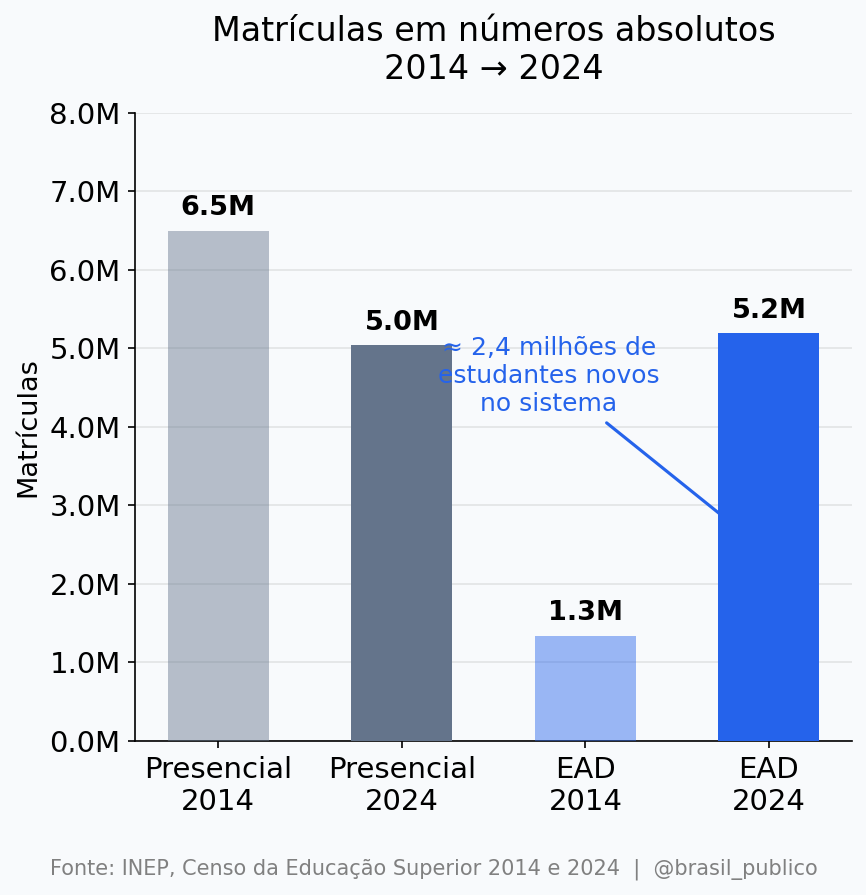

Salvo: grafico2_absolutos.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

categorias = ["Presencial\n2014", "Presencial\n2024", "EAD\n2014", "EAD\n2024"]
valores    = [6_497_889, 5_037_875, 1_341_876, 5_189_391]
cores      = [COR_PRESENCIAL, COR_PRESENCIAL, COR_EAD, COR_EAD]
alphas     = [0.45, 1.0, 0.45, 1.0]

barras = ax.bar(categorias, valores, color=cores, zorder=3, width=0.55)
for barra, alpha in zip(barras, alphas):
    barra.set_alpha(alpha)

for barra, valor in zip(barras, valores):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 120_000,
        f"{valor/1_000_000:.1f}M",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.annotate(
    "≈ 2,4 milhões de\nestudantes novos\nno sistema",
    xy=(3, 2_387_501),
    xytext=(1.8, 4_200_000),
    arrowprops=dict(arrowstyle="->", color=COR_EAD, lw=1.5),
    fontsize=12, color=COR_EAD, ha="center"
)

ax.set_ylabel("Matrículas", fontsize=13)
ax.set_ylim(0, 8_000_000)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_title(
    "Matrículas em números absolutos\n2014 → 2024",
    fontsize=16, pad=16
)
fig.text(
    0.5, 0.01,
    "Fonte: INEP, Censo da Educação Superior 2014 e 2024  |  @brasil_publico",
    ha="center", fontsize=10, color="gray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PASTA_VISUAL / "grafico2_absolutos.png",
            dpi=150, bbox_inches="tight", facecolor=COR_FUNDO)
plt.show()
print("Salvo: grafico2_absolutos.png")